<a href="https://colab.research.google.com/github/samoliverramos/FIAP2026/blob/main/Praticas_Machine_Learning/aula03_regressao_logistica_credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 03 – Classificação de Crédito com Regressão Logística

**Disciplina:** Machine Learning & Modeling  
**Professor:** Samir Ramos  

Nesta aula vamos:

- Entender a diferença entre regressão e classificação.
- Ver o que é regressão **logística** (modelo clássico de classificação binária).
- Treinar um modelo para classificar clientes em **bom pagador (1)** ou **mau pagador (0)**.
- Avaliar o modelo com **accuracy** e **matriz de confusão**.
- Discutir o impacto de errar na aprovação de crédito (visão de negócio).

PASSO 1. Imports e configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

PASSO2. Leitura do CSV dentro do notebook

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

url = "https://raw.githubusercontent.com/samoliverramos/FIAP2026/main/Praticas_Machine_Learning/data/credito_clientes_aula03.csv"
df = pd.read_csv(url)

df.head()

,idade,renda_mensal,tempo_emprego,divida_atual,qtde_atrasos_12m,bom_pagador
0,56,12130,9,35031,0,0
1,69,16222,18,42929,0,0
2,46,2300,2,211,3,1
3,32,10435,23,46577,1,0
4,60,5616,4,39795,2,0


PASSO3. EDA rápida

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   idade             2500 non-null   int64
 1   renda_mensal      2500 non-null   int64
 2   tempo_emprego     2500 non-null   int64
 3   divida_atual      2500 non-null   int64
 4   qtde_atrasos_12m  2500 non-null   int64
 5   bom_pagador       2500 non-null   int64
dtypes: int64(6)
memory usage: 117.3 KB


In [5]:
df.describe()

,idade,renda_mensal,tempo_emprego,divida_atual,qtde_atrasos_12m,bom_pagador
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000
mean,43.734800,10500.96520,16.889600,24958.236000,1.501200,0.227200
std,14.967715,5520.73886,10.001951,14453.527177,1.258663,0.419107
min,18.000000,1016.00000,0.000000,2.000000,0.000000,0.000000
25%,31.000000,5717.50000,8.000000,12417.000000,1.000000,0.000000
50%,44.000000,10807.50000,17.000000,24925.000000,1.000000,0.000000
75%,56.000000,15139.25000,25.000000,37364.500000,2.000000,0.000000
max,69.000000,19994.00000,34.000000,49984.000000,8.000000,1.000000


3.1 - Distribuição da variável alvo:

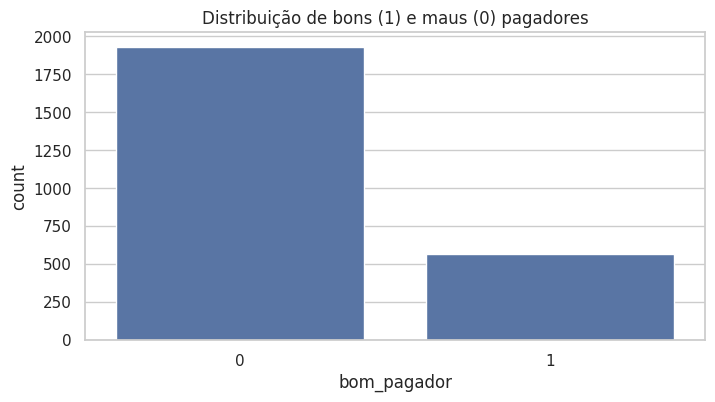

,proportion
bom_pagador,
0,77.28
1,22.72


In [6]:
sns.countplot(x="bom_pagador", data=df)
plt.title("Distribuição de bons (1) e maus (0) pagadores")
plt.show()

df["bom_pagador"].value_counts(normalize=True)*100


3.2 - Scatter simples (para visual analógico ao do app de corridas):

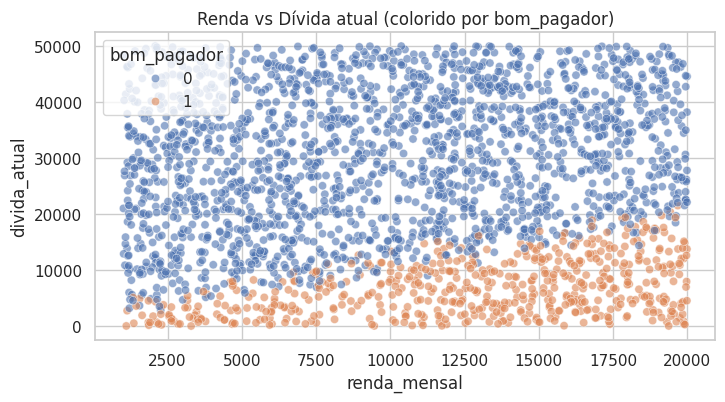

In [7]:
sns.scatterplot(
    x="renda_mensal",
    y="divida_atual",
    hue="bom_pagador",
    data=df,
    alpha=0.6
)
plt.title("Renda vs Dívida atual (colorido por bom_pagador)")
plt.show()

PASSO4. Separando features (X) e alvo (y)

In [8]:
# Features (entradas)
X = df[["idade", "renda_mensal", "tempo_emprego", "divida_atual", "qtde_atrasos_12m"]]

# Alvo (saída / target)
y = df["bom_pagador"]

X.head()


,idade,renda_mensal,tempo_emprego,divida_atual,qtde_atrasos_12m
0,56,12130,9,35031,0
1,69,16222,18,42929,0
2,46,2300,2,211,3
3,32,10435,23,46577,1
4,60,5616,4,39795,2


PASSO5.Train / Test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% teste
    random_state=42,
    stratify=y           # mantém proporção de classes
)

print("Tamanho treino:", X_train.shape[0])
print("Tamanho teste :", X_test.shape[0])

Tamanho treino: 2000
Tamanho teste : 500


PASSO6. Treinando a regressão logística

In [10]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

PASSO7.Interpretando os coeficientes

In [11]:
print("Intercepto:", log_reg.intercept_)

print("\nCoeficientes (na ordem das colunas):")
for col, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"{col:20s}: {coef: .4f}")

Intercepto: [-0.21296813]

Coeficientes (na ordem das colunas):
idade               :  0.1099
renda_mensal        :  0.0040
tempo_emprego       :  0.6777
divida_atual        : -0.0046
qtde_atrasos_12m    : -3.4757


COMENTÁRIOS

- Sinal **positivo** do coeficiente → aumenta a chance de ser **bom pagador (1)**.
- Sinal **negativo** → aumenta a chance de ser **mau pagador (0)**.

Exemplo:
- Coeficiente da `renda_mensal` > 0 → quanto maior a renda, maior a probabilidade de bom pagador (faz sentido).
- Coeficiente da `divida_atual` < 0 → quanto maior a dívida, menor a probabilidade de bom pagador.

PASSO8. Avaliação: accuracy (acurácia) em treino e teste

In [12]:
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Accuracy TREINO: {acc_train:.3f}")
print(f"Accuracy TESTE : {acc_test:.3f}")

Accuracy TREINO: 0.999
Accuracy TESTE : 0.992


PASSO9. Matriz de confusão

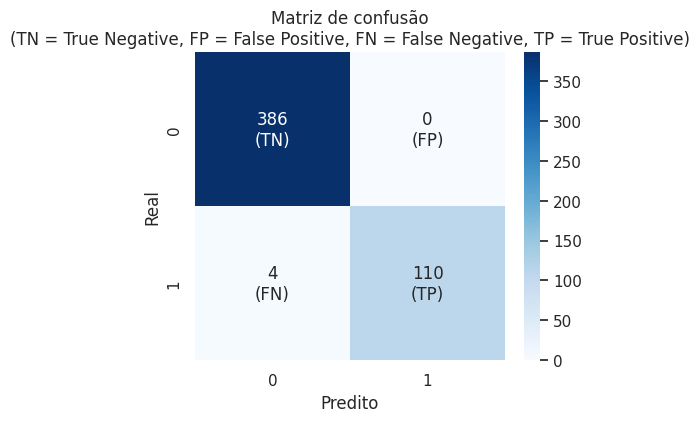

In [19]:
# Calcula a matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)

# Cria um array de rótulos texto para cada célula: TN, FP, FN, TP
# IMPORTANTE: por padrão, para problema binário [0,1],
# a matriz vem como:
# cm = [[TN, FP],
#       [FN, TP]]

labels = [
    [f"{cm[0, 0]}\n(TN)", f"{cm[0, 1]}\n(FP)"],
    [f"{cm[1, 0]}\n(FN)", f"{cm[1, 1]}\n(TP)"]
]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=labels,   # coloca número + sigla em cada célula
    fmt="",         # string vazia, pois já passamos texto pronto em 'annot'
    cmap="Blues"    # mapa de cores (azul mais claro -> azul mais escuro)
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão\n(TN = True Negative, FP = False Positive, FN = False Negative, TP = True Positive)")
plt.show()

MAIS DETALHES....

In [21]:
print(classification_report(y_test, y_test_pred, target_names=["mau_pagador", "bom_pagador"]))

              precision    recall  f1-score   support

 mau_pagador       0.99      1.00      0.99       386
 bom_pagador       1.00      0.96      0.98       114

    accuracy                           0.99       500
   macro avg       0.99      0.98      0.99       500
weighted avg       0.99      0.99      0.99       500



In [ ]:
# O classification_report mostra, para cada classe, as seguintes métricas:
#
# 1) precision (precisão)
#    - Entre todos os clientes que o modelo PREVIU como "bom_pagador",
#      quantos de fato eram bons pagadores?
#    - Fórmula (para a classe "bom_pagador"):
#         precision = VP / (VP + FP)
#      onde:
#        VP (verdadeiro positivo) = modelo acertou quem é bom pagador
#        FP (falso positivo)      = modelo chamou de bom quem era mau
#    - No contexto de crédito:
#      baixa precision para "bom_pagador" significa muitos falsos positivos,
#      ou seja, estamos aprovando crédito para quem não deveria (risco alto).
#
# 2) recall (revocação / sensibilidade)
#    - Entre todos os clientes que REALMENTE são "bom_pagador",
#      quantos o modelo conseguiu encontrar?
#    - Fórmula (para a classe "bom_pagador"):
#         recall = VP / (VP + FN)
#      onde:
#        FN (falso negativo) = modelo chamou de mau quem era bom
#    - No contexto de crédito:
#      baixo recall para "bom_pagador" significa que estamos deixando
#      de aprovar crédito para muita gente que pagaria direitinho
#      (perda de oportunidade de negócio).
#
# 3) f1-score
#    - É a "média harmônica" entre precision e recall.
#    - Serve para equilibrar os dois: só é alto se precision e recall forem bons.
#    - Útil quando há desbalanceamento de classes ou quando queremos
#      um compromisso entre:
#        - não aprovar quem vai dar calote (precision alta)
#        - não recusar quem pagaria em dia (recall alto)
#
# 4) support
#    - É simplesmente quantos exemplos daquela classe existem em y_test.
#    - Exemplo:
#        support para "bom_pagador" = número de clientes bons no conjunto de teste.
#    - Isso ajuda a interpretar as métricas:
#      se uma classe aparece muito pouco (support pequeno), as métricas
#      podem variar bastante (poucos dados).
#
# Além disso, o relatório mostra três linhas de média:
#
# 5) accuracy
#    - Proporção total de acertos (considerando todas as classes).
#    - Fórmula:
#         accuracy = (número de previsões corretas) / (total de exemplos)
#    - Fácil de entender, mas pode enganar em bases desbalanceadas
#      (por exemplo, se quase todo mundo é "bom_pagador").
#
# 6) macro avg
#    - Média simples (não ponderada) das métricas das classes.
#    - Cada classe tem o mesmo peso, independente do support.
#    - Bom para ver se o modelo trata as classes de forma mais "justa".
#
# 7) weighted avg
#    - Média ponderada pelo support de cada classe.
#    - Classes com mais exemplos têm mais peso.
#    - Geralmente essa linha fica mais próxima da realidade global,
#      especialmente quando há desbalanceamento entre "mau_pagador" e "bom_pagador".

PASSO 10. Probabilidades em vez de 0/1

In [20]:
# predict_proba retorna duas colunas: prob de ser 0, prob de ser 1
y_test_proba = log_reg.predict_proba(X_test)
y_test_proba[:5]

array([[1.00000000e+00, 1.76813743e-36],
       [1.80677695e-12, 1.00000000e+00],
       [1.00000000e+00, 2.13503747e-58],
       [1.00000000e+00, 7.67490213e-44],
       [1.00000000e+00, 5.99046451e-43]])

Focando na probabilidade de ser bom pagador (classe 1):

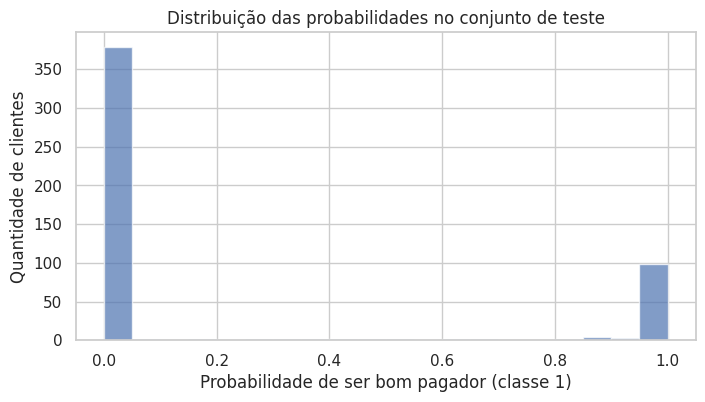

In [16]:
prob_bom = y_test_proba[:, 1]

plt.hist(prob_bom, bins=20, alpha=0.7)
plt.xlabel("Probabilidade de ser bom pagador (classe 1)")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição das probabilidades no conjunto de teste")
plt.show()

COMENTÁRIOS


- A regressão logística não entrega só 0 ou 1.
- Ela entrega uma **probabilidade** de cada classe (0 ou 1).
- Por padrão, o modelo decide:
  - **Classe 1** se prob(1) ≥ 0.5
  - **Classe 0** se prob(1) < 0.5

Na prática, em crédito:
- Podemos querer ser mais conservadores:
  - Ex.: só aprovar (classe 1) se prob(1) ≥ 0.7.

PASSO11. DESAFIOS PARA OS ALUNOS

## Desafio 1 – Mude o tamanho do conjunto de teste

1. Altere o `test_size` de 0.2 para 0.1 e depois para 0.3 em `train_test_split`.
2. Re-treine o modelo e compare os valores de `Accuracy TREINO` e `Accuracy TESTE`.
3. O modelo ficou mais instável? As métricas variaram muito?

## Desafio 2 – Reduza o número de features

1. Crie uma nova matriz X2 com apenas duas features, por exemplo:
   - `renda_mensal`
   - `qtde_atrasos_12m`
2. Repita o processo: train/test split, treino, avaliação, matriz de confusão.
3. Compare o desempenho com o modelo com todas as features.
   - O modelo piorou muito?
   - Aumentou ou diminuiu o risco de aprovar mau pagador?


PASSO 12. CONCLUSÃO

## Conclusão da Aula 03

Hoje você:

- Viu a diferença prática entre **regressão** (número real) e **classificação** (rótulo 0/1).
- Treinou uma **regressão logística** para um problema realista de **crédito**.
- Usou:
  - `train_test_split` para separar treino e teste.
  - `LogisticRegression` para treinar o modelo.
  - `accuracy_score` e matriz de confusão para avaliar.
- Entendeu que:
  - A regressão logística retorna **probabilidades**.
  - Ajustar o limiar (ex.: 0.5 → 0.7) muda o equilíbrio entre risco e oportunidade.

Na próxima aula, podemos:
- Explorar outra técnica de classificação (KNN, Árvore de decisão ou Random Forest).
- Comparar desempenho com a regressão logística neste mesmo problema de crédito.